# Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_top.png" align="left" width="500">

## Setup

Load and/or check for needed environmental variables

In [4]:
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env(".env")  # check environmental variables
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # check packages

GOOGLE_API_KEY=****fphw
LANGSMITH_API_KEY=****f1c7
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=****ials
LANGSMITH_ENDPOINT=****.com
Python 3.12.10 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status    | path                                                                            
---------------------- | -------- | --------- | --------- | --------------------------------------------------------------------------------
langgraph              | >=1.0.0  | 1.0.9     | ✅ OK      | …ion.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages
langchain              | >=1.0.0  | 1.2.10    | ✅ OK      | …ion.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages
langchain-core         | >=1.0.0  | 1.2.14    | ✅ OK      | …ion.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages
langchain-openai       | >=1.0.0  | -         | ❌ Missing | -                                                  

In [5]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Test the connection is made and there are tables in the db

In [8]:
print(db.dialect)
print(db.get_usable_table_names())

sqlite
['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


Define the runtime context to provide the agent and tools with access to the database.

In [9]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [10]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [11]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

In [31]:
from langchain.agents import create_agent

agent = create_agent(
    model="google_genai:gemini-3-flash-preview",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

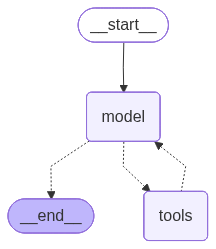

In [14]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [17]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (9901d0ff-a975-4738-94ed-a0ab408cd90d)
 Call ID: 9901d0ff-a975-4738-94ed-a0ab408cd90d
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (f2accdce-284e-486c-b4d7-1d349f9e0aa4)
 Call ID: f2accdce-284e-486c-b4d7-1d349f9e0aa4
  Args:
    query: SELECT COUNT(*) FROM Album;
================================= Tool Message =================================
Name: execute_sql

[(347

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 35.282566916s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [16]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (da2c4a60-b34b-47ba-9a52-ed77f7d9ad77)
 Call ID: da2c4a60-b34b-47ba-9a52-ed77f7d9ad77
  Args:
    query: SELECT T2.Name, AVG(T1.Milliseconds) AS AverageTrackLength FROM tracks AS T1 INNER JOIN genres AS T2 ON T1.GenreId = T2.GenreId GROUP BY T2.Name ORDER BY AverageTrackLength DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: tracks
[SQL: SELECT T2.Name, AVG(T1.Milliseconds) AS AverageTrackLength FROM tracks AS T1 INNER JOIN genres AS T2 ON T1.GenreId = T2.GenreId GROUP BY T2.Name ORDER BY AverageTrackLength DESC LIMIT 1;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ===============

In [25]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================
Tool Calls:
  execute_sql (713bb605-b6cb-4b45-b531-b113d19c98c2)
 Call ID: 713bb605-b6cb-4b45-b531-b113d19c98c2
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================


**Create your own query here!**  Add some questions of your own.

In [33]:
question = "Give me the name of the artist with the most tracks and the most unique tracks"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Give me the name of the artist with the most tracks and the most unique tracks
================================== Ai Message ==================================

[]
Tool Calls:
  execute_sql (0fdc6912-c90f-4bfc-ae08-f12096803873)
 Call ID: 0fdc6912-c90f-4bfc-ae08-f12096803873
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

[]
Tool Calls:
  execute_sql (253d7c8e-bc8d-43d6-aab8-074cc90ee5a5)
 Call ID: 253d7c8e-bc8d-43d6-aab8-074cc90ee5a5
  Args:
    query: PRAGMA table_info(Artist);
================================= Tool Message ===================

### Let's try this Studio